In [1]:
here::i_am("rna_atac/trajectory/v3/01_trajectory_inference.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(BiocParallel))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 8

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM
set.seed(42)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [22]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/07_MOFA_trajectory/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

dir.create(file.path(args$outdir, 'MOFAall'), recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)[day %in% c('D3', 'D3.5', 'D4', 'D4.5', 'D5')] %>% 
    .[celltype_v2 %in% c('Primitive_Streak', 'Early_Mes_EOi','Early_Mes_EOd','Posterior_Mes','HE_Precursor', 'HE', 'Allantois_Precursor')]

In [4]:
table(meta$day)


   D3  D3.5    D4  D4.5    D5 
 4461 13947  6718   881   157 

#### Load Data

In [5]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = F, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()
rna.sce = logNormCounts(rna.sce)

# Trajectory Inference on MOFA factors

In [6]:
# Prepare mofa umap
umap.mtx = meta[,c('cell', 'UMAP1', 'UMAP2')] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()

In [7]:
mofa = fread(file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')) %>% 
    .[match(colnames(rna.sce), cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

pca = fread(file.path(io$basedir, 'results/rna/dimensionality_reduction/sce/none/pca_features1500_pcs15.txt.gz')) %>% 
    .[match(colnames(rna.sce), cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

In [9]:
# Add RNA PCA 
reducedDims(rna.sce)$pca = pca
# Add mofa factors
reducedDims(rna.sce)$mofa = mofa
# Add mofa umap
reducedDims(rna.sce)$mofa_umap = umap.mtx[match(colnames(rna.sce), rownames(umap.mtx)),]

# dm <- DiffusionMap(mofa, n_pcs=ncol(mofa))
# # Add to the SingleCellExperiment object
# reducedDim(rna.sce, "DiffusionMap") <- dm@eigenvectors[,c(1:3)] * 1000

In [10]:
set.seed(42)
rna.sce <- slingshot(rna.sce, 
                     clusterLabels = 'celltype_v2', 
                     start.clus = 'Primitive_Streak', 
                   #  end.clus = c('Allantois_Precursor', 'HE'),
                    # extend = 'n',
                     shrink = TRUE,
                     reducedDim='mofa')

In [15]:
rna.sce$slingshot

class: PseudotimeOrdering 
dim: 26164 2 
metadata(4): lineages mst slingParams curves
pathStats(2): pseudotime weights
cellnames(26164): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
cellData names(2): reducedDim clusterLabels
pathnames(2): Lineage1 Lineage2
pathData names(0):

In [11]:
# Assign cells to lineage, doing this now to make sure it's consistent
# Notice, assignCells is not fixed in which cells are assigned which lineage, even after setting a seed!
set.seed(42)
assign_lineages = tradeSeq:::.assignCells(assays(rna.sce$slingshot)$weights)
#colnames(assign_lineages) = c('Trajectory1', 'Trajectory2')
pseudotime = slingPseudotime(rna.sce$slingshot, na=T)

Traj_assignment = as.data.table(assign_lineages, keep.rownames=T) %>%
    setnames(c('cell', paste0('Trajectory', 1:(length(.)-1))))

Traj1 = as.data.table(pseudotime[,1], keep.rownames=T) %>% 
    .[V1 %in% Traj_assignment[Trajectory1 == 1, cell]] #%>% 
   # .[V2>5 & V2<10]

Traj2 = as.data.table(pseudotime[,2], keep.rownames=T) %>% 
    .[V1 %in% Traj_assignment[Trajectory2 == 1, cell]] #%>% 
    #.[V2>5 & V2<10]

In [12]:
# Combine & add which trajectory
Traj_full = rbind(Traj1[,Traj:='Trajectory1'], Traj2[,Traj:='Trajectory2']) %>%
    setnames(c('cell', 'pseudotime', 'Traj'))

In [13]:
meta2 = rbind(meta[cell %in% Traj_assignment[Trajectory1==1, cell]] %>% 
                  .[, trajectory := 'Traj1'] %>%
                  .[, pseudotime := colData(rna.sce[,cell])$slingPseudotime_1],
              meta[cell %in% Traj_assignment[Trajectory2==1, cell]] %>%
                  .[, trajectory := 'Traj2'] %>%
                  .[, pseudotime := colData(rna.sce[,cell])$slingPseudotime_2])

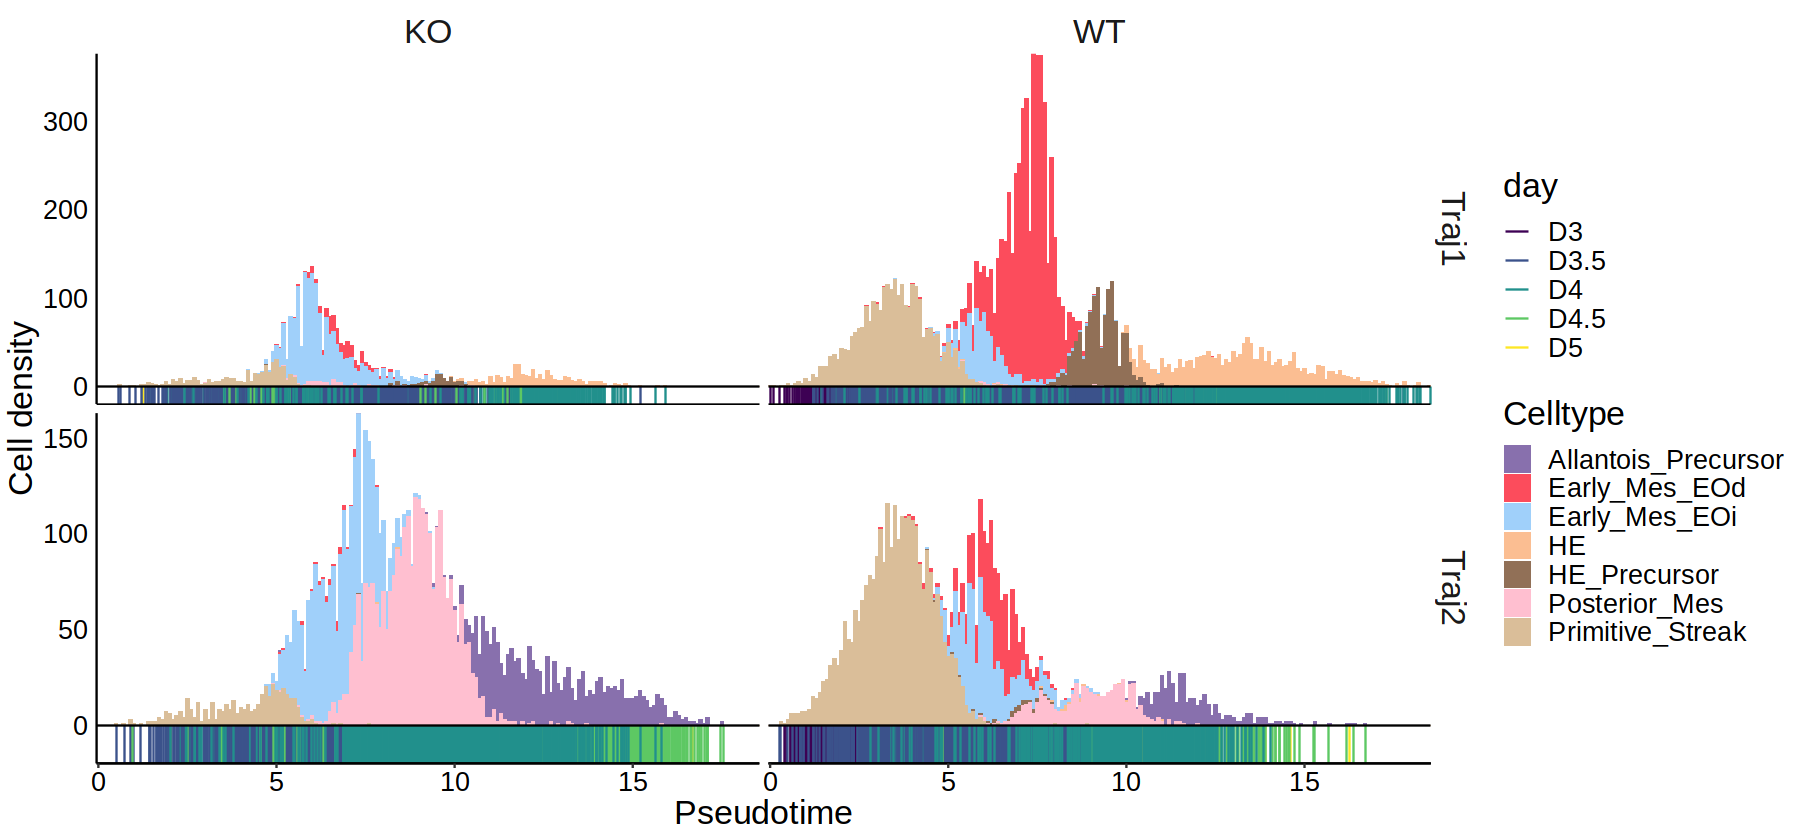

In [16]:
options(repr.plot.width = 15, repr.plot.height=7)
ggplot(meta2, aes(pseudotime, fill=celltype_v1)) + 
    geom_histogram(binwidth=0.1, position='stack') + 
    scale_colour_manual(values = opts$days.colors, name='day') + 
    scale_fill_manual(values = opts$celltype_v2.colors, name='Celltype') +
    geom_segment(aes(x = pseudotime, xend = pseudotime, y = 0, yend = -20, col=day)) + 
    scale_x_continuous(expand=c(0,0)) + 
    scale_y_continuous(expand=c(0,0)) + 
    geom_hline(yintercept=0, color='black') +
    geom_hline(yintercept=-20, color='black') +
    # geom_vline(xintercept = 13, color='red') + 
    # geom_vline(xintercept = 2, color='red') + 
    xlab('Pseudotime') + ylab('Cell density') + 
    facet_grid(rows = vars(trajectory), cols = vars(genotype),scales='free_y') + 
    theme_classic() + 
    theme(text = element_text(size=20),
          axis.text = element_text(color='black'),
       #   axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          strip.background = element_blank(),
          strip.text = element_text(size=20),
          legend.position='right')

Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Removed 1 rows containing missing values (`position_stack()`).”


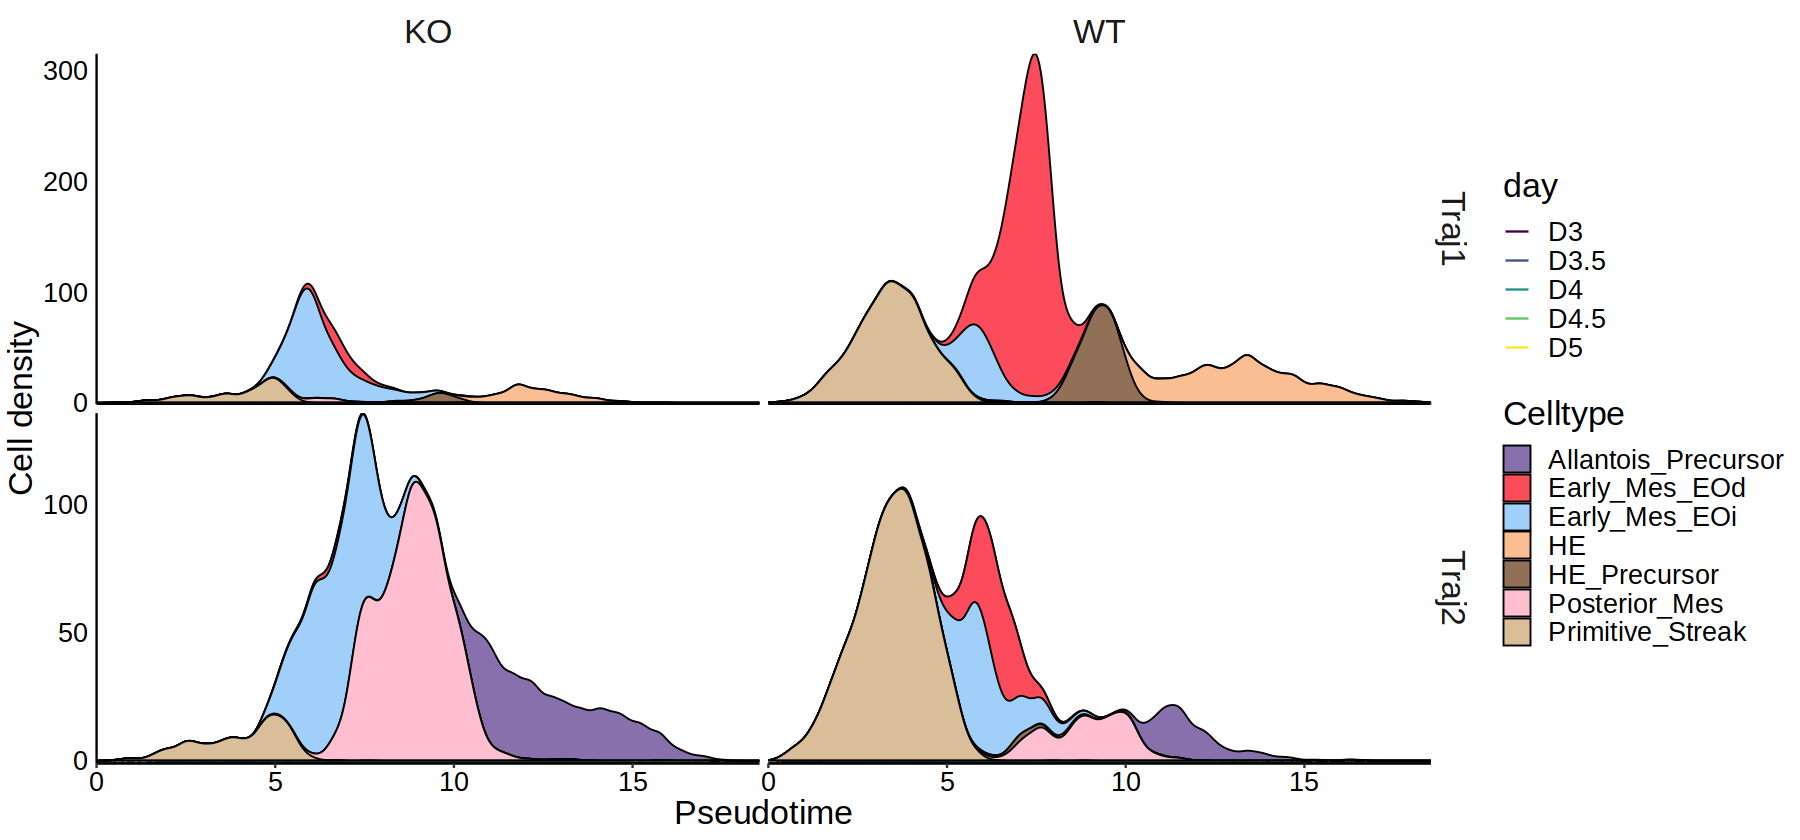

In [17]:
options(repr.plot.width = 15, repr.plot.height=7)
ggplot(meta2, aes(pseudotime, fill=celltype_v1)) + 
    # geom_histogram(binwidth=0.1, position='stack') + 
    geom_density(aes(y = after_stat(density * n/10)), position = 'stack', color = 'black', linewidth = 0.4, bw = 0.2) + 
    scale_colour_manual(values = opts$days.colors, name='day') + 
    scale_fill_manual(values = opts$celltype_v2.colors, name='Celltype') +
    geom_segment(aes(x = pseudotime, xend = pseudotime, y = 0, yend = -1, col=day)) + 
    scale_x_continuous(expand=c(0,0)) + 
    scale_y_continuous(expand=c(0,0)) + 
    geom_hline(yintercept=0, color='black') +
    geom_hline(yintercept=-1, color='black') +
    # geom_vline(xintercept = 13, color='red') + 
    # geom_vline(xintercept = 2, color='red') + 
    xlab('Pseudotime') + ylab('Cell density') + 
    facet_grid(rows = vars(trajectory), cols = vars(genotype),scales='free_y') + 
    theme_classic() + 
    theme(text = element_text(size=20),
          axis.text = element_text(color='black'),
       #   axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          strip.background = element_blank(),
          strip.text = element_text(size=20),
          legend.position='right')

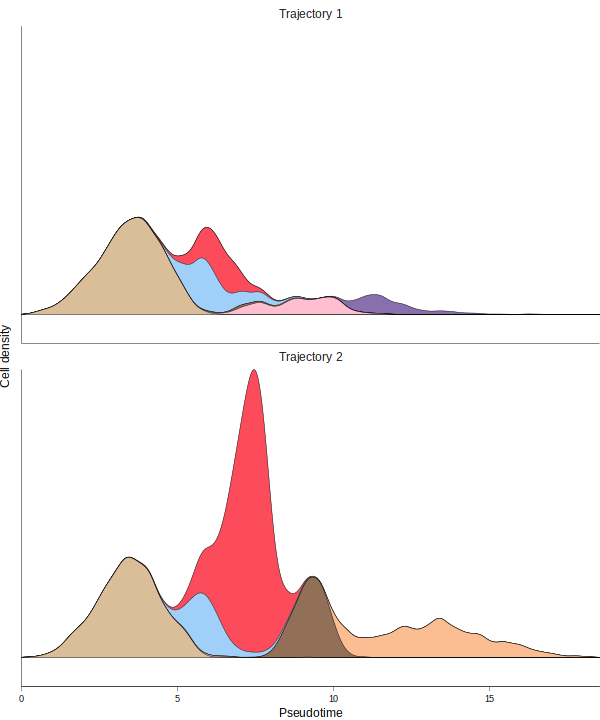

In [47]:
# facet_labels = c()
p1 = ggplot(meta2[genotype=='WT'][,trajectory := factor(trajectory, levels = c('Traj2', 'Traj1'))], aes(pseudotime, fill=celltype_v1)) + 
    # geom_histogram(binwidth=0.1, position='stack') + 
    geom_density(aes(y = after_stat(density * n/10)), position = 'stack', color = 'black', linewidth = 0.1, bw = 0.2) + 
    scale_colour_manual(values = opts$days.colors, name='day') + 
    scale_fill_manual(values = opts$celltype_v2.colors, name='Celltype') +
    scale_x_continuous(expand=c(0,0)) + 
    scale_y_continuous(expand=c(0,0)) + 
    # geom_vline(xintercept = c(2, 10), color='red', linetype = 'dashed', linewidth = 0.2) + 
    xlab('Pseudotime') + ylab('Cell density') + 
    facet_wrap(~trajectory, ncol = 1, 
               scales='fixed', 
               labeller = labeller(trajectory = c('Traj1' = 'Trajectory 2', 'Traj2' = 'Trajectory 1'))) + # Silly thing but we ended up switching the labels around
    theme_classic() + 
    theme(text = element_text(size=6),
          axis.text = element_text(color='black'),
          axis.title = element_text(size = 7),
          axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line = element_line(linewidth = 0.1),
          axis.ticks=element_line(linewidth=0.1),
          strip.background = element_blank(),
          strip.text = element_text(size=7),
          panel.spacing = unit(0, "lines"),
          plot.margin = unit(c(0, 0, 0, 0), "mm"),
          legend.position='none')

p1_values = ggplot_build(p1)
p1 = p1 +    
    geom_segment(aes(x = pseudotime, xend = pseudotime, y = 0, yend = -max(p1_values$data[[1]]$ymax)/10, col=day), linewidth = 0.001) + 
    geom_hline(yintercept=c(0,-max(p1_values$data[[1]]$ymax)/10), linewidth = 0.1, color='black')

options(repr.plot.width = 5, repr.plot.height=6)
p1

ggsave(file.path(args$outdir, 'MOFAall/multiome_trajectory_density.pdf'), 
       plot = p1,
       width = 30, 
       height = 55, 
       units = "mm")

In [48]:
# Define custom color palettes with smooth transition around 0.5
palette1 <- colorRampPalette(c("darkblue", "orange", "chartreuse", 'chartreuse4'))(100) # YS trajectory palette
palette2 <- colorRampPalette(c("darkblue", "orange", "orchid1", 'darkorchid4'))(100)  # Alnt trajectory palette

all_cells = fread(args$metadata)[genotype == 'WT']

p1_umap = ggplot(all_cells[], aes(UMAP1, UMAP2)) +
    #ggrastr::rasterise(geom_point(size = -0.10, color='black'), dpi = 600) + 
    ggrastr::rasterise(geom_point(size = -0.3, color='grey90'), dpi = 600) + 
    ggrastr::rasterise(geom_point(data = meta2[trajectory == 'Traj1' & genotype == 'WT'], aes(color=pseudotime), size = -0.3), dpi = 900) +
    scale_color_gradientn(colors = palette1, name = 'Pseudotime',
                          breaks = c(0, 5, 10, 15),
                       guide = guide_colorbar(
                            barwidth = 2, barheight = 0.5,
                            frame.colour = "black",
                            ticks.colour = 'black')) +  # Apply custom palette 1
    scale_x_continuous(expand=c(0.01,0.01)) + 
    scale_y_continuous(expand=c(0.01,0.01)) + 
    coord_fixed() + 
    theme_void() + 
    theme(legend.position = c(0.77,0.10),
          legend.direction = 'horizontal',
          legend.title = element_text(size = 6), #element_text(vjust = 1, size = 25),
          legend.text = element_text(vjust = 2, size = 6))

p2_umap = ggplot(all_cells[], aes(UMAP1, UMAP2)) +
    #ggrastr::rasterise(geom_point(size = -0.10, color='black'), dpi = 600) + 
    ggrastr::rasterise(geom_point(size = -0.3, color='grey90'), dpi = 600) + 
    ggrastr::rasterise(geom_point(data = meta2[trajectory == 'Traj2' & genotype == 'WT'], aes(color=pseudotime), size = -0.3), dpi = 900) +
    scale_color_gradientn(colors = palette2, name = 'Pseudotime',
                          breaks = c(0, 5, 10, 15),
                          labels = c(0, 5, 10, 15),
                       guide = guide_colorbar(
                            barwidth = 2, barheight = 0.5,
                            frame.colour = "black",
                            ticks.colour = 'black')) +  # Apply custom palette 1
    scale_x_continuous(expand=c(0.01,0.01)) + 
    scale_y_continuous(expand=c(0.01,0.01)) + 
    coord_fixed() + 
    theme_void() + 
    theme(legend.position = c(0.77,0.10),
          legend.direction = 'horizontal',
          legend.title = element_text(size = 6), #element_text(vjust = 1, size = 25),
          legend.text = element_text(vjust = 2, size = 6))

width = 5
options(repr.plot.width=width, repr.plot.height=width*6/7.5)
#ggarrange(p2_umap, p1_umap, ncol = 1)

ggsave(file.path(args$outdir, 'MOFAall/multiome_trajectory_umap.pdf'), 
       plot = ggarrange(p2_umap, NULL, p1_umap, ncol = 1, heights = c(1, -0.05, 1)),
       width = 30, 
       height = 55, 
       units = "mm")

In [49]:
#ggarrange(p1, ggarrange(p2_umap, p1_umap, ncol = 1))
ggsave(file.path(args$outdir, 'MOFAall/multiome_trajectory_combined.pdf'), 
       plot = ggarrange(p1, ggarrange(NULL, p2_umap, p1_umap, NULL, heights = c(0.2, 1, 1, 0.2), ncol = 1)),
       width = 69, 
       height = 41, 
       units = "mm")